In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

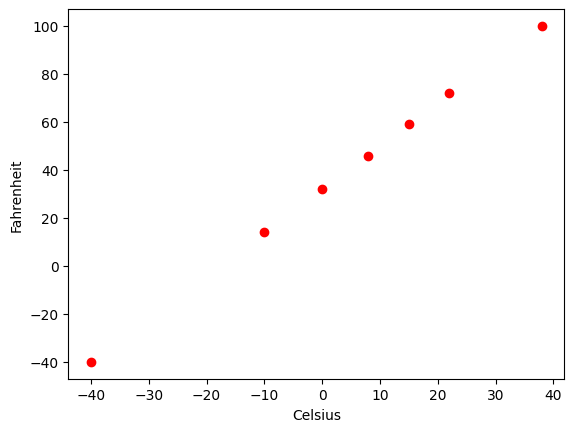

In [3]:
plt.scatter(celsius, fahrenheit, color='red', label='Datos de entrenamiento')
plt.xlabel('Celsius')
plt.ylabel('Fahrenheit')       
plt.show()

In [4]:
X_train = celsius
Y_train = fahrenheit

In [5]:
print("Creando el modelo...")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=1, input_shape=(1,)))

Creando el modelo...


c:\Users\elyix\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
print("compilando el modelo...")
model.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

compilando el modelo...


In [7]:
print("Entreando el modelo...")
epoch_hist = model.fit(X_train, Y_train, epochs=500, verbose=False)

Entreando el modelo...


Evaluando el modelo entrenado
Keys: 
dict_keys(['loss'])


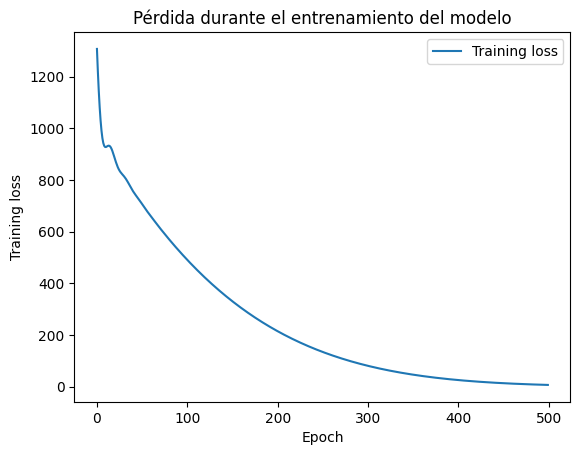

In [8]:
print("Evaluando el modelo entrenado")
print("Keys: ")
print(epoch_hist.history.keys())


plt.plot(epoch_hist.history['loss'])
plt.title('Pérdida durante el entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])
plt.show()

In [9]:
Temp_C = 100
Temp_C_array = np.array([Temp_C])
Temp_F = model.predict(Temp_C_array)
print("Temperatura en Celsius:" + str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Temperatura en Celsius:[[211.3381]]


In [10]:
Temp_F = 9/5 * Temp_C + 32
print("Temperatura de Ecuacion:" + str(Temp_F))

Temperatura de Ecuacion:212.0


Modificaciones

In [11]:
df_temperatura = pd.read_csv("celsius_a_fahrenheit.csv")
print(df_temperatura.columns)

Index(['Celsius', 'Fahrenheit'], dtype='str')


In [12]:
print(df_temperatura.head())

   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


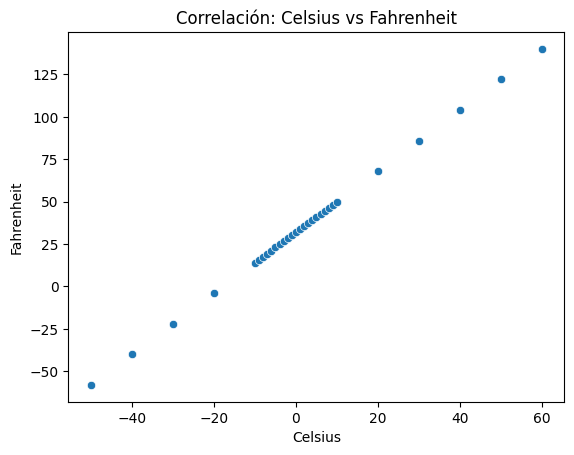

In [13]:
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title("Correlación: Celsius vs Fahrenheit")
plt.show()

In [14]:
x = np.array(df_temperatura['Celsius'], dtype=float)
y = np.array(df_temperatura['Fahrenheit'], dtype=float)

X_train = x
Y_train = y

In [15]:
print("Creando el modelo con 2 capas ocultas...")
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida  = tf.keras.layers.Dense(units=1)

modelo1 = tf.keras.Sequential([oculta1, oculta2, salida])
modelo1.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

print("Entrenando el modelo...")
hist1 = modelo1.fit(X_train, Y_train, epochs=500, verbose=False)

print("\nPesos de la capa oculta 1:")
print(oculta1.get_weights())
print("\nPesos de la capa oculta 2:")
print(oculta2.get_weights())
print("\nPesos de la capa de salida:")
print(salida.get_weights())

Creando el modelo con 2 capas ocultas...
Entrenando el modelo...


c:\Users\elyix\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Pesos de la capa oculta 1:
[array([[ 0.73382074, -0.23143691, -0.48722583]], dtype=float32), array([ 3.0858254,  2.865532 , -3.0756273], dtype=float32)]

Pesos de la capa oculta 2:
[array([[-0.5444564 , -0.43091473, -0.8466475 ],
       [-0.48874465, -1.0837971 , -1.337229  ],
       [ 1.006743  ,  0.89095   ,  0.7054223 ]], dtype=float32), array([-3.1626143, -3.139174 , -3.1539762], dtype=float32)]

Pesos de la capa de salida:
[array([[-0.91136444],
       [-0.5559249 ],
       [-1.2421916 ]], dtype=float32), array([3.1357827], dtype=float32)]


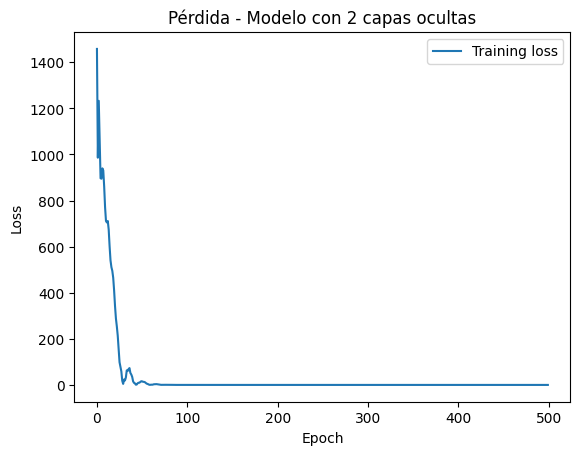

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicción con 2 capas ocultas para 100°C: 212.0000°F
Valor real (ecuación): 212.0°F


In [16]:
# Gráfica de pérdidas - Modelo con 2 capas ocultas
plt.plot(hist1.history['loss'])
plt.title('Pérdida - Modelo con 2 capas ocultas')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training loss'])
plt.show()

# Predicción con este modelo
Temp_C = 100
pred1 = modelo1.predict(np.array([Temp_C]))
print(f"Predicción con 2 capas ocultas para {Temp_C}°C: {pred1[0][0]:.4f}°F")
print(f"Valor real (ecuación): {9/5 * Temp_C + 32}°F")

In [17]:
print("Creando el modelo con 3 capas ocultas...")
oculta1b = tf.keras.layers.Dense(units=4, input_shape=[1])
oculta2b = tf.keras.layers.Dense(units=4)
oculta3b = tf.keras.layers.Dense(units=4)
salidab  = tf.keras.layers.Dense(units=1)

modelo2 = tf.keras.Sequential([oculta1b, oculta2b, oculta3b, salidab])
modelo2.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

print("Entrenando el modelo...")
hist2 = modelo2.fit(X_train, Y_train, epochs=500, verbose=False)

print("\nPesos de la capa oculta 1:")
print(oculta1b.get_weights())
print("\nPesos de la capa oculta 2:")
print(oculta2b.get_weights())
print("\nPesos de la capa oculta 3:")
print(oculta3b.get_weights())
print("\nPesos de la capa de salida:")
print(salidab.get_weights())

Creando el modelo con 3 capas ocultas...
Entrenando el modelo...

Pesos de la capa oculta 1:
[array([[-0.04593819,  0.02286755,  0.28803366,  0.511957  ]],
      dtype=float32), array([-1.804193 , -1.4523267,  2.16015  ,  2.5649557], dtype=float32)]

Pesos de la capa oculta 2:
[array([[-0.15135297,  0.63572466,  0.68216735,  0.35443208],
       [ 0.10194457, -0.05275306, -0.12124327,  0.06390584],
       [ 0.1754689 , -0.3634699 ,  0.27359325,  0.13829745],
       [ 0.67639834,  0.1299458 ,  0.8508388 , -0.59873086]],
      dtype=float32), array([ 2.4252076 , -0.79667795,  2.5384333 , -2.4703457 ], dtype=float32)]

Pesos de la capa oculta 3:
[array([[-1.018105  , -0.42788175, -0.06442476, -0.34978324],
       [-0.41821018, -0.04134968,  0.31785598,  0.6578585 ],
       [ 0.43030426, -0.7590932 , -0.27074206, -0.8494657 ],
       [ 0.53722185,  0.7298616 ,  0.19977795, -0.1444988 ]],
      dtype=float32), array([-2.57702  , -2.558331 , -2.2753263, -2.4799068], dtype=float32)]

Pesos de 

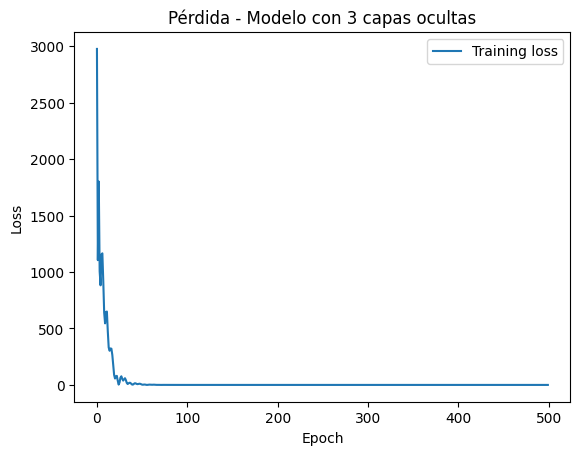

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicción con 3 capas ocultas para 100°C: 212.0000°F
Valor real (ecuación): 212.0°F


In [18]:
plt.plot(hist2.history['loss'])
plt.title('Pérdida - Modelo con 3 capas ocultas')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training loss'])
plt.show() 

pred2 = modelo2.predict(np.array([Temp_C]))
print(f"Predicción con 3 capas ocultas para {Temp_C}°C: {pred2[0][0]:.4f}°F")
print(f"Valor real (ecuación): {9/5 * Temp_C + 32}°F")